# Comparativa de latencia: EBM vs RF+SHAP

         Latencia por muestra (1 alerta) y entrenamiento        
Dataset   modelo    fit(s)  predict/1(ms)  explain/1(ms)
----------------------------------------------------------------
NSL-KDD   EBM       149.85         0.1683         0.1126
NSL-KDD   RF          0.30        41.0670         4.2789
   -> explicar 1 muestra: RF+SHAP es 38x mas lento que EBM

Mirai     EBM       321.50         0.1287         0.1291
Mirai     RF          1.08        27.7817         4.4199
   -> explicar 1 muestra: RF+SHAP es 34x mas lento que EBM

DS2OS     EBM      1559.75         0.1514         0.1234
DS2OS     RF          4.73        31.1761         2.5854
   -> explicar 1 muestra: RF+SHAP es 21x mas lento que EBM



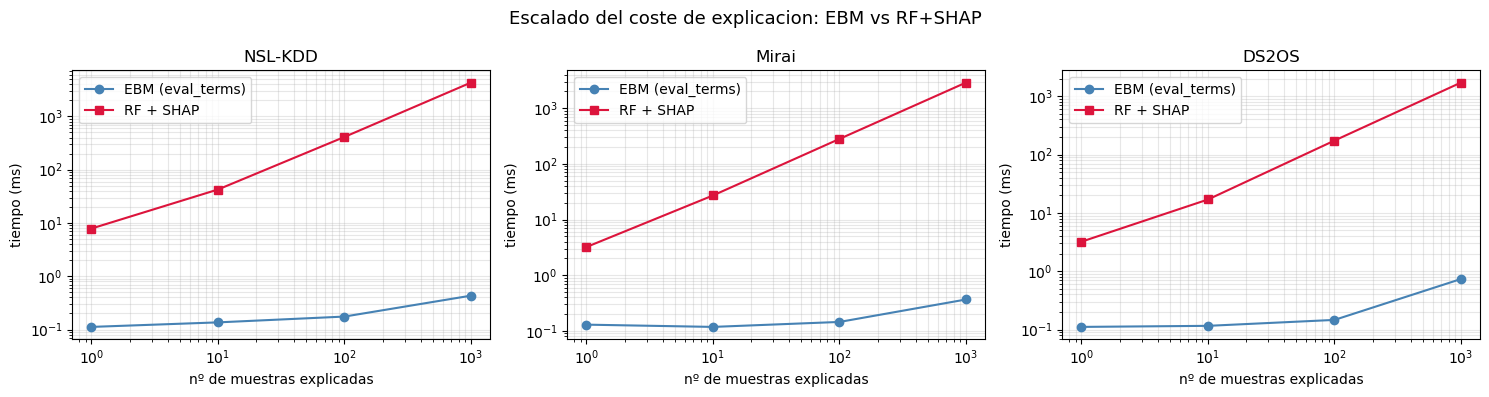

Figura guardada: latencia_escalado.png


In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path('C:/Users/user/TFM')
le = json.load(open(BASE / 'latencia_ebm.json', encoding='utf-8'))
lr = json.load(open(BASE / 'latencia_rf.json',  encoding='utf-8'))
DS = ['NSL-KDD', 'Mirai', 'DS2OS']

print('=' * 64)
print('  Latencia por muestra (1 alerta) y entrenamiento'.center(64))
print('=' * 64)
print(f'{"Dataset":<10}{"modelo":<7}{"fit(s)":>9}{"predict/1(ms)":>15}{"explain/1(ms)":>15}')
print('-' * 64)
for ds in DS:
    for nom, d in [('EBM', le.get(ds)), ('RF', lr.get(ds))]:
        if not d:
            continue
        fit = d.get('fit_s')
        fit_txt = f'{fit:.2f}' if fit else '-'
        print(f'{ds:<10}{nom:<7}{fit_txt:>9}{d["predict_1_ms"][0]:>15.4f}{d["explain_1_ms"][0]:>15.4f}')
    if le.get(ds) and lr.get(ds):
        ratio = lr[ds]['explain_1_ms'][0] / le[ds]['explain_1_ms'][0]
        print(f'   -> explicar 1 muestra: RF+SHAP es {ratio:,.0f}x mas lento que EBM')
    print()

# Figura de escalado (log-log)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, ds in zip(axes, DS):
    if not (le.get(ds) and lr.get(ds)):
        ax.set_visible(False); continue
    be, br = le[ds]['scaling'], lr[ds]['scaling']
    xs = sorted(int(k) for k in be)
    ax.plot(xs, [be[str(x)]['explain_ms'] for x in xs], 'o-',
            label='EBM (eval_terms)', color='steelblue')
    ax.plot(xs, [br[str(x)]['explain_ms'] for x in xs], 's-',
            label='RF + SHAP', color='crimson')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('nº de muestras explicadas'); ax.set_ylabel('tiempo (ms)')
    ax.set_title(ds); ax.legend(); ax.grid(True, which='both', alpha=0.3)
fig.suptitle('Escalado del coste de explicacion: EBM vs RF+SHAP', fontsize=13)
plt.tight_layout()
plt.savefig('latencia_escalado.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: latencia_escalado.png')
